<a href="https://colab.research.google.com/github/JesusArevalo16/NCAA-Prediction-Project/blob/main/notebooks/NCAA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predicciones NCAA

In [41]:
import os

os.listdir('/content')

['.config',
 'WNCAATourneySeeds.csv',
 'WTeams.csv',
 'WRegularSeasonCompactResults.csv',
 'WNCAATourneyCompactResults.csv',
 'SampleSubmissionStage1.csv',
 'sample_data']

In [42]:
# =========================================
# 1. IMPORTAR LIBRERÍAS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Configuración visual
pd.set_option("display.max_columns", 50)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [43]:
# =========================================
# 2. CONFIGURACIÓN DE DIRECTORIOS
# =========================================

DATA_DIR = Path("/content")

print("Directorio configurado:", DATA_DIR)

Directorio configurado: /content


In [44]:
# =========================================
# 3. CARGA DE DATOS
# =========================================

teams = pd.read_csv(DATA_DIR / "WTeams.csv")

regular_season = pd.read_csv(
    DATA_DIR / "WRegularSeasonCompactResults.csv"
)

tourney = pd.read_csv(
    DATA_DIR / "WNCAATourneyCompactResults.csv"
)

seeds = pd.read_csv(
    DATA_DIR / "WNCAATourneySeeds.csv"
)

submission = pd.read_csv(
    DATA_DIR / "SampleSubmissionStage1.csv"
)

print("Datos cargados correctamente")

Datos cargados correctamente


In [45]:
# =========================================
# 4. VERIFICAR DATOS
# =========================================

print("Equipos:", teams.shape)
print("Temporada regular:", regular_season.shape)
print("Torneo:", tourney.shape)
print("Seeds:", seeds.shape)
print("Submission:", submission.shape)

Equipos: (379, 2)
Temporada regular: (140825, 8)
Torneo: (1717, 8)
Seeds: (1744, 3)
Submission: (519144, 2)


In [46]:
# =========================================
# 5. PRIMER VISTAZO A LOS DATOS
# =========================================

teams.head()

,TeamID,TeamName
0,3101,Abilene Chr
1,3102,Air Force
2,3103,Akron
3,3104,Alabama
4,3105,Alabama A&M


In [47]:
regular_season.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1998,18,3104,91,3202,41,H,0
1,1998,18,3163,87,3221,76,H,0
2,1998,18,3222,66,3261,59,H,0
3,1998,18,3307,69,3365,62,H,0
4,1998,18,3349,115,3411,35,H,0


In [48]:
tourney.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1998,137,3104,94,3422,46,H,0
1,1998,137,3112,75,3365,63,H,0
2,1998,137,3163,93,3193,52,H,0
3,1998,137,3198,59,3266,45,H,0
4,1998,137,3203,74,3208,72,A,0


In [49]:
['WNCAATourneySeeds.csv',
 'WTeams.csv',
 'WRegularSeasonCompactResults.csv',
 'WNCAATourneyCompactResults.csv',
 'SampleSubmissionStage1.csv']

['WNCAATourneySeeds.csv',
 'WTeams.csv',
 'WRegularSeasonCompactResults.csv',
 'WNCAATourneyCompactResults.csv',
 'SampleSubmissionStage1.csv']

In [50]:
GENDER = "M"
GENDER = "W"


In [51]:
DATA_DIR = Path("./sample_data")
DATA_DIR = Path(".")

In [52]:
# Directorios
DATA_DIR = Path(".")
OUTPUT_DIR = Path("./outputs")

GENDER = "W"

In [53]:
print(f"WTeams.csv: {teams.shape}")
print(f"WRegularSeasonCompactResults.csv: {regular_season.shape}")
print(f"WNCAATourneyCompactResults.csv: {tourney.shape}")
print(f"WNCAATourneySeeds.csv: {seeds.shape}")
print(f"SampleSubmissionStage1.csv: {submission.shape}")

WTeams.csv: (379, 2)
WRegularSeasonCompactResults.csv: (140825, 8)
WNCAATourneyCompactResults.csv: (1717, 8)
WNCAATourneySeeds.csv: (1744, 3)
SampleSubmissionStage1.csv: (519144, 2)


In [54]:
reg_detailed = None
massey = None
team_stats = None
massey_feat = None

In [55]:
def build_win_rates(df):
    wins = df.groupby(['Season', 'WTeamID']).size().reset_index(name='Wins')
    losses = df.groupby(['Season', 'LTeamID']).size().reset_index(name='Losses')

    win_loss = pd.merge(wins, losses, left_on=['Season', 'WTeamID'], right_on=['Season', 'LTeamID'], how='outer').fillna(0)
    win_loss['TeamID'] = win_loss['WTeamID'].fillna(win_loss['LTeamID']).astype(int)
    win_loss['TotalGames'] = win_loss['Wins'] + win_loss['Losses']
    win_loss['WinRate'] = win_loss['Wins'] / win_loss['TotalGames']
    return win_loss[['Season', 'TeamID', 'WinRate']]

In [56]:
def get_seed_numeric(seeds_df):
    # Extract only the numeric part of the seed string after the first character
    seeds_df['Seed_numeric'] = seeds_df['Seed'].apply(lambda x: int(''.join(filter(str.isdigit, x[1:]))))
    return seeds_df[['Season', 'TeamID', 'Seed_numeric']]

In [57]:
win_rates = build_win_rates(regular_season)
seeds_clean = get_seed_numeric(seeds)

In [58]:
win_rates = build_win_rates(regular_season)
seeds_clean = get_seed_numeric(seeds)

In [59]:
# --- Simplified ELO Calculation --- #
# A more robust ELO system would involve iterating game by game and updating ratings.
# This is a simplified version to get a seasonal ELO.

def calculate_elo(df, initial_elo=1500, K=32):
    elo_ratings = {}
    # Initialize ELO for all teams across all seasons
    all_teams = pd.concat([df['WTeamID'], df['LTeamID']]).unique()
    all_seasons = df['Season'].unique()

    for season in sorted(all_seasons):
        elo_ratings[season] = {team_id: initial_elo for team_id in all_teams}

    # Process games season by season, day by day
    for season in sorted(all_seasons):
        season_df = df[df['Season'] == season].sort_values(by='DayNum')
        for index, row in season_df.iterrows():
            wteam = row['WTeamID']
            lteam = row['LTeamID']

            Rw = elo_ratings[season].get(wteam, initial_elo)
            Rl = elo_ratings[season].get(lteam, initial_elo)

            expected_win = 1 / (1 + 10**((Rl - Rw) / 400))
            expected_loss = 1 / (1 + 10**((Rw - Rl) / 400))

            elo_ratings[season][wteam] += K * (1 - expected_win)
            elo_ratings[season][lteam] += K * (0 - expected_loss)

    # Convert final season ELOs to DataFrame
    elo_df_list = []
    for season, team_elos in elo_ratings.items():
        for team_id, elo in team_elos.items():
            elo_df_list.append({'Season': season, 'TeamID': team_id, 'ELO_season_end': elo})
    return pd.DataFrame(elo_df_list)

elo_season_end = calculate_elo(regular_season)
print("ELO season end ratings calculated.")

ELO season end ratings calculated.


In [60]:
# --- Build Team Statistics --- #

def build_team_stats(df):
    team_stats_list = []
    for season in df['Season'].unique():
        season_df = df[df['Season'] == season]

        # Stats for winning teams
        wteam_stats = season_df.groupby('WTeamID').agg(
            WAvgScore=('WScore', 'mean'),
            WNumGames=('WTeamID', 'count')
        ).reset_index().rename(columns={'WTeamID': 'TeamID'})

        # Stats for losing teams
        lteam_stats = season_df.groupby('LTeamID').agg(
            LAvgScore=('LScore', 'mean'),
            LNumGames=('LTeamID', 'count')
        ).reset_index().rename(columns={'LTeamID': 'TeamID'})

        # Merge them
        team_stats_season = pd.merge(wteam_stats, lteam_stats, on='TeamID', how='outer').fillna(0)
        team_stats_season['Season'] = season

        # Calculate combined stats
        team_stats_season['AvgScore'] = (team_stats_season['WAvgScore'] * team_stats_season['WNumGames'] + \
                                        team_stats_season['LAvgScore'] * team_stats_season['LNumGames']) / \
                                       (team_stats_season['WNumGames'] + team_stats_season['LNumGames'])
        team_stats_season['TotalGames'] = team_stats_season['WNumGames'] + team_stats_season['LNumGames']

        team_stats_list.append(team_stats_season[['Season', 'TeamID', 'AvgScore', 'TotalGames']])
    return pd.concat(team_stats_list, ignore_index=True)

team_stats = build_team_stats(regular_season)
print("Team statistics calculated.")

Team statistics calculated.


In [61]:
# --- Placeholder for Massey Features --- #
# Massey rankings are complex and typically involve external data or specific algorithms.
# For now, we'll create an empty DataFrame as a placeholder.
# If you have Massey rankings data, you would load or calculate it here and populate this DataFrame.
massey_feat = pd.DataFrame(columns=['Season', 'TeamID', 'MasseyRank']) # Example columns
print("Massey features placeholder created. Please populate if you have the data.")

Massey features placeholder created. Please populate if you have the data.


In [62]:
# --- Define build_matchup_dataset function --- #

def build_matchup_dataset(tourney_df, elo_df, seeds_df, win_rates_df, team_stats_df, massey_df):
    # Prepare the tourney data to have two rows per game (Team1 vs Team2, Team2 vs Team1)
    df_temp = tourney_df.copy()
    df_temp['Result'] = 1 # Winner
    df_temp['TeamID1'] = df_temp['WTeamID']
    df_temp['TeamID2'] = df_temp['LTeamID']

    df_temp2 = tourney_df.copy()
    df_temp2['Result'] = 0 # Loser
    df_temp2['TeamID1'] = df_temp2['LTeamID']
    df_temp2['TeamID2'] = df_temp2['WTeamID']

    matchups = pd.concat([df_temp, df_temp2], ignore_index=True)
    matchups = matchups[['Season', 'DayNum', 'TeamID1', 'TeamID2', 'Result']]

    # Merge with seeds
    matchups = pd.merge(matchups, seeds_df, left_on=['Season', 'TeamID1'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'Seed_numeric': 'Seed1'}).drop(columns=['TeamID'])

    matchups = pd.merge(matchups, seeds_df, left_on=['Season', 'TeamID2'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'Seed_numeric': 'Seed2'}).drop(columns=['TeamID'])

    # Merge with win rates
    matchups = pd.merge(matchups, win_rates_df, left_on=['Season', 'TeamID1'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'WinRate': 'WinRate1'}).drop(columns=['TeamID'])

    matchups = pd.merge(matchups, win_rates_df, left_on=['Season', 'TeamID2'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'WinRate': 'WinRate2'}).drop(columns=['TeamID'])

    # Merge with ELO ratings
    matchups = pd.merge(matchups, elo_df, left_on=['Season', 'TeamID1'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'ELO_season_end': 'ELO1'}).drop(columns=['TeamID'])

    matchups = pd.merge(matchups, elo_df, left_on=['Season', 'TeamID2'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'ELO_season_end': 'ELO2'}).drop(columns=['TeamID'])

    # Merge with team stats
    matchups = pd.merge(matchups, team_stats_df, left_on=['Season', 'TeamID1'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'AvgScore': 'AvgScore1', 'TotalGames': 'TotalGames1'}).drop(columns=['TeamID'])

    matchups = pd.merge(matchups, team_stats_df, left_on=['Season', 'TeamID2'], right_on=['Season', 'TeamID'], how='left')
    matchups = matchups.rename(columns={'AvgScore': 'AvgScore2', 'TotalGames': 'TotalGames2'}).drop(columns=['TeamID'])

    # Merge with Massey features (if massey_df is not empty)
    if not massey_df.empty:
        matchups = pd.merge(matchups, massey_df, left_on=['Season', 'TeamID1'], right_on=['Season', 'TeamID'], how='left')
        matchups = matchups.rename(columns={'MasseyRank': 'MasseyRank1'}).drop(columns=['TeamID'])

        matchups = pd.merge(matchups, massey_df, left_on=['Season', 'TeamID2'], right_on=['Season', 'TeamID'], how='left')
        matchups = matchups.rename(columns={'MasseyRank': 'MasseyRank2'}).drop(columns=['TeamID'])

    # Feature Engineering for matchup differences
    matchups['SeedDiff'] = matchups['Seed1'] - matchups['Seed2']
    matchups['WinRateDiff'] = matchups['WinRate1'] - matchups['WinRate2']
    matchups['ELODiff'] = matchups['ELO1'] - matchups['ELO2']
    matchups['AvgScoreDiff'] = matchups['AvgScore1'] - matchups['AvgScore2']
    # If Massey data exists, add MasseyRankDiff
    if not massey_df.empty:
        matchups['MasseyRankDiff'] = matchups['MasseyRank1'] - matchups['MasseyRank2']

    # Handle potential NaN values from left joins (e.g., if a team had no regular season games or no seed)
    # Consider filling with 0 or a median/mean based on domain knowledge
    matchups = matchups.fillna(0) # Filling with 0 as a default, can be adjusted

    return matchups

print("build_matchup_dataset function defined.")

build_matchup_dataset function defined.


In [63]:
matchup_data = build_matchup_dataset(
    tourney,
    elo_season_end,
    seeds_clean,
    win_rates,
    team_stats,
    massey_feat
)

In [64]:
# Define the feature columns for the model
FEATURE_COLS = [
    'Seed1', 'Seed2', 'WinRate1', 'WinRate2', 'ELO1', 'ELO2',
    'AvgScore1', 'AvgScore2', 'TotalGames1', 'TotalGames2',
    'SeedDiff', 'WinRateDiff', 'ELODiff', 'AvgScoreDiff'
]

# Include MasseyRankDiff if massey_feat was populated
if 'MasseyRank1' in matchup_data.columns and 'MasseyRank2' in matchup_data.columns:
    FEATURE_COLS.extend(['MasseyRank1', 'MasseyRank2', 'MasseyRankDiff'])

print(FEATURE_COLS)


['Seed1', 'Seed2', 'WinRate1', 'WinRate2', 'ELO1', 'ELO2', 'AvgScore1', 'AvgScore2', 'TotalGames1', 'TotalGames2', 'SeedDiff', 'WinRateDiff', 'ELODiff', 'AvgScoreDiff']


In [65]:
import lightgbm as lgb
import xgboost as xgb

In [66]:
print(matchup_data.shape)
print(FEATURE_COLS)

(3434, 19)
['Seed1', 'Seed2', 'WinRate1', 'WinRate2', 'ELO1', 'ELO2', 'AvgScore1', 'AvgScore2', 'TotalGames1', 'TotalGames2', 'SeedDiff', 'WinRateDiff', 'ELODiff', 'AvgScoreDiff']


In [67]:
print(matchup_data["Season"].unique())

[1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2021 2022 2023 2024 2025]


In [68]:
print(sorted(matchup_data["Season"].unique())[-10:])

[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

# Features
X = matchup_data[FEATURE_COLS].fillna(0)

# Target
y = matchup_data["Result"]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
model = LogisticRegression(max_iter=1000)

# Entrenamiento
model.fit(X_train, y_train)

# Predicciones
preds = model.predict_proba(X_test)[:,1]

# LogLoss
loss = log_loss(y_test, preds)

print("LogLoss:", round(loss,4))

LogLoss: 0.4356


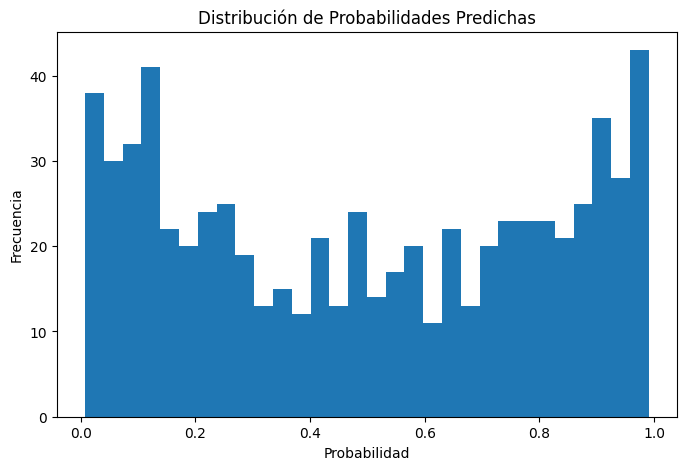

In [71]:
import matplotlib.pyplot as plt

# Histograma de probabilidades
plt.figure(figsize=(8,5))

plt.hist(preds, bins=30)

plt.title("Distribución de Probabilidades Predichas")
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")

plt.show()

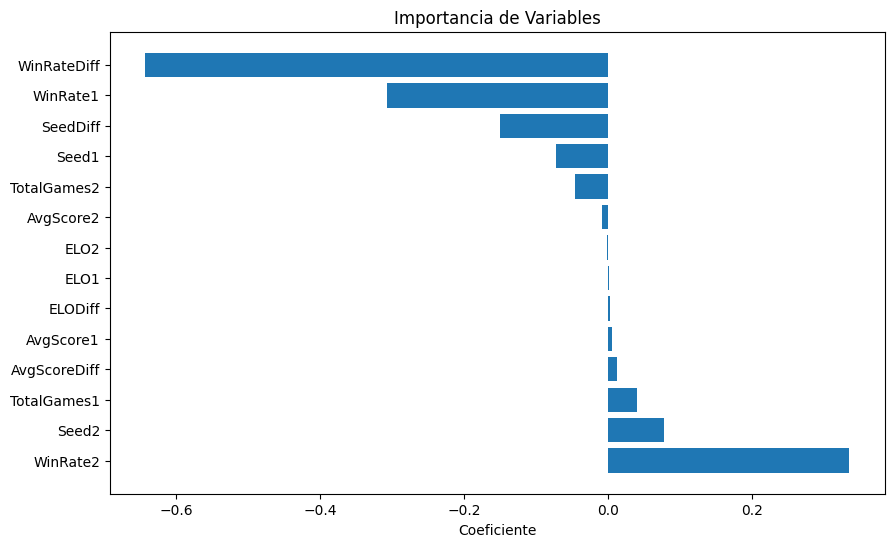

In [72]:
feature_importance = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Coeficiente": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coeficiente",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coeficiente"]
)

plt.title("Importancia de Variables")
plt.xlabel("Coeficiente")

plt.show()

In [73]:
# =========================================
# GENERAR PREDICCIONES PARA KAGGLE
# =========================================

submission.head()

,ID,Pred
0,2022_1101_1102,0.5
1,2022_1101_1103,0.5
2,2022_1101_1104,0.5
3,2022_1101_1105,0.5
4,2022_1101_1106,0.5


In [74]:
# =========================================
# SEPARAR IDS
# =========================================

submission["Season"] = submission["ID"].apply(
    lambda x: int(x.split("_")[0])
)

submission["Team1"] = submission["ID"].apply(
    lambda x: int(x.split("_")[1])
)

submission["Team2"] = submission["ID"].apply(
    lambda x: int(x.split("_")[2])
)

submission.head()

,ID,Pred,Season,Team1,Team2
0,2022_1101_1102,0.5,2022,1101,1102
1,2022_1101_1103,0.5,2022,1101,1103
2,2022_1101_1104,0.5,2022,1101,1104
3,2022_1101_1105,0.5,2022,1101,1105
4,2022_1101_1106,0.5,2022,1101,1106


In [76]:
# =========================================
# CREAR FEATURES PARA SUBMISSION
# =========================================

# Add features for Team1 by merging pre-computed team statistics
submission = pd.merge(
    submission,
    seeds_clean.rename(columns={'Seed_numeric': 'Seed1', 'TeamID': 'Team1'}),
    on=['Season', 'Team1'],
    how='left'
)
submission = pd.merge(
    submission,
    win_rates.rename(columns={'WinRate': 'WinRate1', 'TeamID': 'Team1'}),
    on=['Season', 'Team1'],
    how='left'
)
submission = pd.merge(
    submission,
    elo_season_end.rename(columns={'ELO_season_end': 'ELO1', 'TeamID': 'Team1'}),
    on=['Season', 'Team1'],
    how='left'
)
submission = pd.merge(
    submission,
    team_stats.rename(columns={'AvgScore': 'AvgScore1', 'TotalGames': 'TotalGames1', 'TeamID': 'Team1'}),
    on=['Season', 'Team1'],
    how='left'
)

# Add features for Team2 by merging pre-computed team statistics
submission = pd.merge(
    submission,
    seeds_clean.rename(columns={'Seed_numeric': 'Seed2', 'TeamID': 'Team2'}),
    on=['Season', 'Team2'],
    how='left'
)
submission = pd.merge(
    submission,
    win_rates.rename(columns={'WinRate': 'WinRate2', 'TeamID': 'Team2'}),
    on=['Season', 'Team2'],
    how='left'
)
submission = pd.merge(
    submission,
    elo_season_end.rename(columns={'ELO_season_end': 'ELO2', 'TeamID': 'Team2'}),
    on=['Season', 'Team2'],
    how='left'
)
submission = pd.merge(
    submission,
    team_stats.rename(columns={'AvgScore': 'AvgScore2', 'TotalGames': 'TotalGames2', 'TeamID': 'Team2'}),
    on=['Season', 'Team2'],
    how='left'
)

# Calculate difference features
submission['SeedDiff'] = submission['Seed1'] - submission['Seed2']
submission['WinRateDiff'] = submission['WinRate1'] - submission['WinRate2']
submission['ELODiff'] = submission['ELO1'] - submission['ELO2']
submission['AvgScoreDiff'] = submission['AvgScore1'] - submission['AvgScore2']

# Fill any remaining NaNs (e.g., if a team has no data for a given season)
# This is crucial for prediction as models don't handle NaNs by default
submission = submission.fillna(0)

print("Submission features created.")
submission.head()

Submission features created.


,ID,Pred,Season,Team1,Team2,Seed1,WinRate1,ELO1,AvgScore1,TotalGames1,Seed2,WinRate2,ELO2,AvgScore2,TotalGames2,SeedDiff,WinRateDiff,ELODiff,AvgScoreDiff
0,2022_1101_1102,0.5,2022,1101,1102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022_1101_1103,0.5,2022,1101,1103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022_1101_1104,0.5,2022,1101,1104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022_1101_1105,0.5,2022,1101,1105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022_1101_1106,0.5,2022,1101,1106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
# =========================================
# CREAR VARIABLES DIFERENCIA
# =========================================

submission["SeedDiff"] = submission["Seed1"] - submission["Seed2"]

submission["WinRateDiff"] = (
    submission["WinRate1"] - submission["WinRate2"]
)

submission["ELODiff"] = (
    submission["ELO1"] - submission["ELO2"]
)

submission["AvgScoreDiff"] = (
    submission["AvgScore1"] - submission["AvgScore2"]
)

submission["GamesDiff"] = (
    submission["TotalGames1"] - submission["TotalGames2"]
)

In [78]:
# =========================================
# GENERAR PREDICCIONES
# =========================================

X_submission = submission[FEATURE_COLS].fillna(0)

submission["Pred"] = model.predict_proba(
    X_submission
)[:,1]

submission.head()

,ID,Pred,Season,Team1,Team2,Seed1,WinRate1,ELO1,AvgScore1,TotalGames1,Seed2,WinRate2,ELO2,AvgScore2,TotalGames2,SeedDiff,WinRateDiff,ELODiff,AvgScoreDiff,GamesDiff
0,2022_1101_1102,0.487415,2022,1101,1102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022_1101_1103,0.487415,2022,1101,1103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022_1101_1104,0.487415,2022,1101,1104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022_1101_1105,0.487415,2022,1101,1105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022_1101_1106,0.487415,2022,1101,1106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
# =========================================
# CREAR CSV FINAL
# =========================================

final_submission = submission[["ID", "Pred"]]

final_submission.to_csv(
    "SubmissionFinal.csv",
    index=False
)

print("Archivo generado correctamente")

Archivo generado correctamente
